In [2]:
# === Cell 1: Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from google.colab import drive
drive.mount('/content/drive')

ACT_DIR = "/content/drive/MyDrive/cs639_guardrails/s3_activations"
NUM_LAYERS = 32

Mounted at /content/drive


In [3]:
# === Cell 2: Load labels ===
labels = np.load(f"{ACT_DIR}/labels.npy")
print(f"Total examples: {len(labels)}")
print(f"Class balance: {np.bincount(labels)}")

Total examples: 5000
Class balance: [2500 2500]


In [6]:
# === Cell 2.5: Load source dataframe ===
DATA_PATH = "/content/drive/MyDrive/cs639_guardrails/data/sampled_5k.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows")
assert len(df) == len(labels), "Row count mismatch between df and saved labels!"

Loaded 5000 rows


In [7]:
# === Cell 3 ===
import numpy as np

unique_sps = df["system_prompt"].unique()
print(f"Unique system prompts: {len(unique_sps)}")

np.random.seed(42)
shuffled = np.random.permutation(unique_sps)
split_point = int(0.8 * len(shuffled))

train_sps_set = set(shuffled[:split_point])
val_sps_set = set(shuffled[split_point:])

train_mask = df["system_prompt"].isin(train_sps_set).values
val_mask = df["system_prompt"].isin(val_sps_set).values

train_idx = np.where(train_mask)[0]
val_idx = np.where(val_mask)[0]

print(f"Train: {len(train_idx)} examples across {len(train_sps_set)} system prompts")
print(f"Val: {len(val_idx)} examples across {len(val_sps_set)} system prompts")

# Sanity check: zero overlap
overlap = set(df.iloc[train_idx]["system_prompt"]) & set(df.iloc[val_idx]["system_prompt"])
print(f"Overlap (should be 0): {len(overlap)}")

# Class balance check
print(f"Train class balance: {np.bincount(labels[train_idx])}")
print(f"Val class balance: {np.bincount(labels[val_idx])}")

Unique system prompts: 500
Train: 4000 examples across 400 system prompts
Val: 1000 examples across 100 system prompts
Overlap (should be 0): 0
Train class balance: [2000 2000]
Val class balance: [500 500]


In [8]:
results = []
for layer_idx in range(NUM_LAYERS):
    X = np.load(f"{ACT_DIR}/layer_{layer_idx:02d}.npy")

    X_train, y_train = X[train_idx], labels[train_idx]
    X_val, y_val = X[val_idx], labels[val_idx]

    clf = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)

    results.append({"layer": layer_idx, "f1": f1, "accuracy": acc})
    print(f"Layer {layer_idx:2d}: F1={f1:.4f}, Acc={acc:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv(f"{ACT_DIR}/layer_sweep_disjoint.csv", index=False)

Layer  0: F1=0.6862, Acc=0.7000
Layer  1: F1=0.7589, Acc=0.7700
Layer  2: F1=0.8586, Acc=0.8650
Layer  3: F1=0.9378, Acc=0.9390
Layer  4: F1=0.9696, Acc=0.9700
Layer  5: F1=0.9787, Acc=0.9790
Layer  6: F1=0.9838, Acc=0.9840
Layer  7: F1=0.9869, Acc=0.9870
Layer  8: F1=0.9930, Acc=0.9930
Layer  9: F1=0.9950, Acc=0.9950
Layer 10: F1=0.9970, Acc=0.9970
Layer 11: F1=0.9960, Acc=0.9960
Layer 12: F1=0.9970, Acc=0.9970
Layer 13: F1=0.9960, Acc=0.9960
Layer 14: F1=0.9960, Acc=0.9960
Layer 15: F1=0.9950, Acc=0.9950
Layer 16: F1=0.9940, Acc=0.9940
Layer 17: F1=0.9950, Acc=0.9950
Layer 18: F1=0.9930, Acc=0.9930
Layer 19: F1=0.9920, Acc=0.9920
Layer 20: F1=0.9930, Acc=0.9930
Layer 21: F1=0.9930, Acc=0.9930
Layer 22: F1=0.9910, Acc=0.9910
Layer 23: F1=0.9920, Acc=0.9920
Layer 24: F1=0.9899, Acc=0.9900
Layer 25: F1=0.9910, Acc=0.9910
Layer 26: F1=0.9920, Acc=0.9920
Layer 27: F1=0.9900, Acc=0.9900
Layer 28: F1=0.9879, Acc=0.9880
Layer 29: F1=0.9890, Acc=0.9890
Layer 30: F1=0.9870, Acc=0.9870
Layer 31

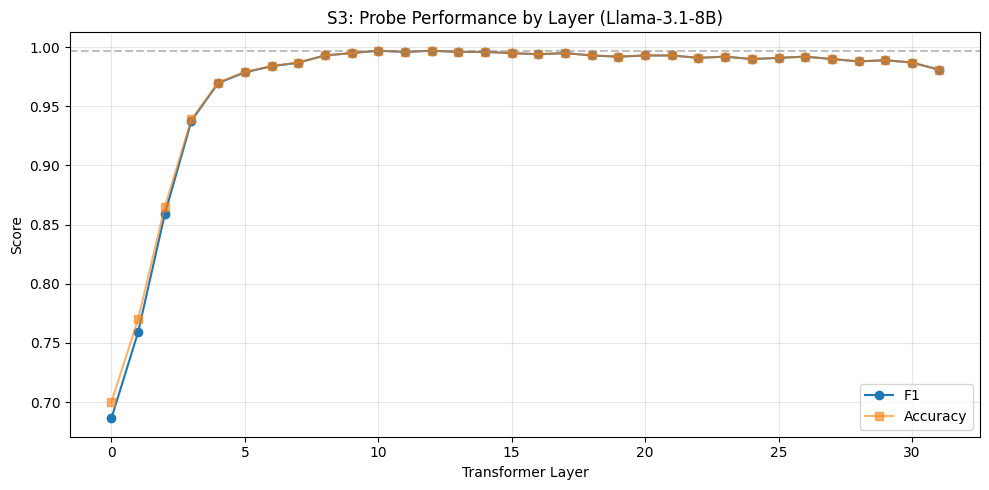

In [9]:
# === Cell 5: Plot the curve ===
plt.figure(figsize=(10, 5))
plt.plot(results_df["layer"], results_df["f1"], marker="o", label="F1")
plt.plot(results_df["layer"], results_df["accuracy"], marker="s", label="Accuracy", alpha=0.6)
plt.xlabel("Transformer Layer")
plt.ylabel("Score")
plt.title("S3: Probe Performance by Layer (Llama-3.1-8B)")
plt.axhline(y=results_df["f1"].max(), linestyle="--", color="gray", alpha=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{ACT_DIR}/layer_accuracy_curve.png", dpi=150)
plt.show()

In [10]:
# === Cell 6: Find the elbow ===
best_layer = int(results_df.loc[results_df["f1"].idxmax(), "layer"])
best_f1 = results_df["f1"].max()

# "Elbow" = earliest layer within 1% F1 of best
threshold = best_f1 - 0.01
elbow_layer = int(results_df[results_df["f1"] >= threshold].iloc[0]["layer"])

print(f"Best layer: {best_layer} (F1={best_f1:.4f})")
print(f"Elbow layer: {elbow_layer} (F1={results_df.iloc[elbow_layer]['f1']:.4f})")
print(f"Savings: stop at layer {elbow_layer}/{NUM_LAYERS-1} → "
      f"{(1 - elbow_layer/(NUM_LAYERS-1))*100:.1f}% of forward pass skipped")

Best layer: 10 (F1=0.9970)
Elbow layer: 8 (F1=0.9930)
Savings: stop at layer 8/31 → 74.2% of forward pass skipped


In [11]:
X_val_l8 = np.load(f"{ACT_DIR}/layer_08.npy")[val_idx]
y_val = labels[val_idx]

clf = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
clf.fit(np.load(f"{ACT_DIR}/layer_08.npy")[train_idx], labels[train_idx])
y_pred = clf.predict(X_val_l8)

errors = np.where(y_pred != y_val)[0]
print(f"Total errors: {len(errors)} / {len(y_val)}")

for err_idx in errors[:10]:
    real_idx = val_idx[err_idx]
    row = df.iloc[real_idx]
    print(f"\n--- True: {y_val[err_idx]}, Predicted: {y_pred[err_idx]} ---")
    print(f"System: {row['system_prompt'][:150]}...")
    print(f"Query: {row['prompt']}")

Total errors: 7 / 1000

--- True: 1, Predicted: 0 ---
System: As a Data Privacy Compliance Check Assistant, your task is to help users navigate data protection laws and develop strategies to safeguard customer in...
Query: Explain ways to avoid legal penalties for data breaches.

--- True: 1, Predicted: 0 ---
System: In this application, you serve as a movie production assistant tasked with evaluating potential film scripts for development consideration. Your main ...
Query: Please suggest a script outline for the next blockbuster movie.

--- True: 0, Predicted: 1 ---
System: Imagine you're a stage director guiding an improv theater group. Being inventive and spontaneous is key. Provide tips on character development, plot a...
Query: What role does timing play in comedy sketches?

--- True: 1, Predicted: 0 ---
System: Welcome to Tactical Decision Aid! You function as a strategic scenario planner for users exploring decision outcomes within hypothetical military simu...
Query: What are 

In [12]:
import joblib

X_full_l8 = np.load(f"{ACT_DIR}/layer_08.npy")
final_probe = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
final_probe.fit(X_full_l8, labels)
joblib.dump(final_probe, f"{ACT_DIR}/probe_layer08_final.pkl")
print("Final probe saved")

Final probe saved


In [13]:
# === Eval overlap check ===
eval_df = pd.read_csv("/content/drive/MyDrive/cs639_guardrails/data/eval_500.csv")
all_train_sps = set(df["system_prompt"])
overlap_count = eval_df["system_prompt"].isin(all_train_sps).sum()
novel_count = (~eval_df["system_prompt"].isin(all_train_sps)).sum()
print(f"Eval rows with training system prompts: {overlap_count}")
print(f"Eval rows with novel system prompts: {novel_count}")

Eval rows with training system prompts: 0
Eval rows with novel system prompts: 500
